# Dokumentasi Eksperimen Unimodal

**Notebook ini di-generate dari `scripts/build_unimodal_notebook.py`** sebagai dokumentasi visual untuk semua eksperimen unimodal — yaitu **CNN/CNN_TL pada citra wajah** dan **FCNN/CNN1D pada facial landmark** (raw 2D coordinates, FACS distance, MediaPipe blendshape, dan FACS+Blendshape concatenation).

## Scope notebook
1. Setup & protokol eksperimen (B1 / B2 / B3, hyperparameters, dataset)
2. Loading semua hasil `results.json` ke struktur tabular
3. Master table (16 baris × 6 kolom)
4. Visualisasi:
   - Heatmap master table per scheme
   - Top-10 leaderboard
   - B1 / B2 / B3 scenario comparison
   - Landmark source comparison (face-api.js vs MediaPipe)
   - Feature comparison (raw / FACS / Blendshape / FACS+Blendshape)
   - Architecture comparison (FCNN vs CNN1D)
   - Confusion matrix top model per kategori
   - Per-class F1
   - Training curves
   - Resource usage (waktu train, params, peak VRAM)
   - Class distribution
   - Cross-dataset (Primer vs KDEF)

> Eksperimen utama dijalankan via Python scripts di `scripts/`. Notebook ini bersifat dokumentasi & visualisasi — semua angka diambil dari `results.json` hasil eksperimen.

---


## 1. Setup & Protokol Eksperimen

### Skenario imbalance B1 / B2 / B3

| Scenario | Sampler | Augmentation per batch |
|---|---|---|
| **B1** | shuffle uniform | none |
| **B2** | `WeightedRandomSampler` (prob ∝ 1/class_count) | none |
| **B3** | `WeightedRandomSampler` | per-`__getitem__` on-the-fly aug |

**Augmentation per modalitas (B3):**
- **Landmark**: hflip dengan proper 68-pt left/right swap (p=0.5) → rotate ±10° → scale 0.95-1.05 → translate ±2% → per-coord Gaussian noise σ=0.005
- **Image**: hflip (p=0.5) → rotate ±10° reflect-pad → brightness ±10% → contrast ×0.9-1.1

### Hyperparameters

```
Adam, lr=1e-3 (lr=1e-4 untuk CNN_TL ResNet-18 finetune)
batch=32, epochs_max=50, patience=15, seed=42
loss=CrossEntropyLoss (no class weight — sampler yang handle)
```

### Dimensi eksperimen

| Dimensi | Nilai |
|---|---|
| Skema kelas | 3c (positive / neutral / negative), 7c (neutral / happy / sad / angry / fearful / disgusted / surprised) |
| Sumber landmark | MediaPipe FaceLandmarker v2 (478→68 dlib-mapping), face-api.js (native 68 dlib via TinyFace+Landmark68) |
| Sumber citra | Face crop 224×224×3 dari MediaPipe bbox (OBS recording) |
| Arsitektur citra | CNN scratch (4 conv blocks, 27M params), CNN_TL (ResNet-18 ImageNet, 11M params) |
| Arsitektur landmark | FCNN (5-dense), CNN1D (Conv1d on (2, 68) sequence) |
| Representasi landmark | Raw 2D coords (136), FACS Euclidean distance (28), ARKit Blendshape (52, MP only), FACS+Blendshape concat (80) |

### Dataset utama (Primer)

`data/dataset_frontonly_conf60/` — confidence ≥ 0.6, per-user split (no leakage).

- train 5287 / 29 users
- val 579 / 5 users
- test 929 / 3 users
- total 6795 dari 37 users


In [1]:
# Imports
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT = Path('..').resolve()
PRIMER = PROJECT / 'models' / 'frontonly_conf60'
KDEF = PROJECT / 'models' / 'benchmark' / 'kdef_7class'
FIG_ROOT = PROJECT / 'docs' / 'figures' / 'unimodal'

UNIMODAL_DIRS = {'raw_136','facs_28','blendshape_52','facs_plus_bs_80',
                 'cnn_scratch','cnn_tl'}
print('PROJECT:', PROJECT)
print('Figure dir:', FIG_ROOT)

PROJECT: /mnt/extended-home/fitra_dosen/2025_iris_fer_taufik/MultimodalEmoLearn
Figure dir: /mnt/extended-home/fitra_dosen/2025_iris_fer_taufik/MultimodalEmoLearn/docs/figures/unimodal


## 2. Loading Semua Hasil Unimodal

Setiap `results.json` punya struktur:

```
{
  "config": {...},
  "runs": {
    "<run_key>": {
      "test": {"macro_f1", "weighted_f1", "accuracy", "confusion_matrix", "classification_report", ...},
      "training": {"history": [...per-epoch...], "best_epoch", "elapsed_sec", "peak_vram_mb", ...},
      "hyperparams": {...},
      "model": {"n_params", ...},
      ...
    }
  }
}
```


In [2]:
def load_results_dir(scheme_dir):
    out = []
    if not scheme_dir.exists(): return out
    for results_file in scheme_dir.glob('*/results.json'):
        method = results_file.parent.name
        if method not in UNIMODAL_DIRS:
            continue
        d = json.load(open(results_file))
        for run_key, run in d.get('runs', {}).items():
            run['_method_dir'] = method
            run['_run_key'] = run_key
            out.append(run)
    return out

primer = {}
for scheme, sk in [('3class','3c'), ('7class','7c')]:
    primer[sk] = load_results_dir(PRIMER / scheme / 'Unified')
    print(f'Primer {sk}: {len(primer[sk])} runs')

kdef = {}
for scheme, sk in [('3class','3c'), ('7class','7c')]:
    p = KDEF / scheme / 'Unified'
    kdef[sk] = load_results_dir(p) if p.exists() else []
    print(f'KDEF {sk}: {len(kdef[sk])} runs')

Primer 3c: 48 runs
Primer 7c: 48 runs
KDEF 3c: 6 runs
KDEF 7c: 6 runs


## 3. Master Table

14 baris landmark + 2 baris image × 6 kolom (3c × {B1, B2, B3} + 7c × {B1, B2, B3}).


In [3]:
def parse_landmark_key(rk):
    parts = rk.split('_')
    if parts[0] not in ('mediapipe', 'faceapi'):
        return None
    return {
        'source': 'MP' if parts[0]=='mediapipe' else 'FA',
        'feature': '_'.join(parts[1:-3]),
        'arch': parts[-3],
        'scenario': parts[-2].upper(),
        'scheme': parts[-1],
    }

def build_master_table():
    rows = {}
    for scheme in ('3c','7c'):
        for r in primer[scheme]:
            mf1 = r.get('test',{}).get('macro_f1')
            if mf1 is None: continue
            md_ = r['_method_dir']
            rk = r['_run_key']
            info = parse_landmark_key(rk)
            if info:
                key = (info['feature'], info['source'], info['arch'].upper())
                col = f"{info['scheme']}-{info['scenario']}"
                rows.setdefault(key, {})[col] = mf1
            elif md_ in ('cnn_scratch','cnn_tl'):
                parts = rk.split('_')
                key = ('image', '—', md_.upper())
                col = f"{parts[-1]}-{parts[-2].upper()}"
                rows.setdefault(key, {})[col] = mf1
    df = pd.DataFrame.from_dict(rows, orient='index')
    df.index.names = ['feature','source','arch']
    df = df.reindex(columns=['3c-B1','3c-B2','3c-B3','7c-B1','7c-B2','7c-B3'])
    return df.sort_index()

master = build_master_table()
master.style.format('{:.4f}', na_rep='-').background_gradient(cmap='RdYlGn', axis=None)

### Highlight cell terbaik per scheme

Best per kolom — angka dengan latar hijau gelap di tabel di atas.


In [4]:
best_per_col = master.idxmax()
print('Best per kolom:')
for col, idx in best_per_col.items():
    if pd.notna(master.loc[idx, col]):
        print(f'  {col}: {idx}  →  {master.loc[idx, col]:.4f}')

Best per kolom:
  3c-B1: ('facs_28', 'FA', 'FCNN')  →  0.7585
  3c-B2: ('facs_28', 'FA', 'FCNN')  →  0.7489
  3c-B3: ('facs_28', 'FA', 'FCNN')  →  0.7372
  7c-B1: ('raw_136', 'FA', 'CNN1D')  →  0.3256
  7c-B2: ('facs_28', 'FA', 'CNN1D')  →  0.3211
  7c-B3: ('facs_28', 'FA', 'CNN1D')  →  0.3117


## 4. Visualisasi

Semua figure dihasilkan oleh `scripts/build_unimodal_figures.py`. Untuk regenerate setelah eksperimen baru selesai, jalankan ulang script tersebut — cell di bawah ini sekadar menampilkan PNG yang sudah ada.

### 4.1 Heatmap Master Table


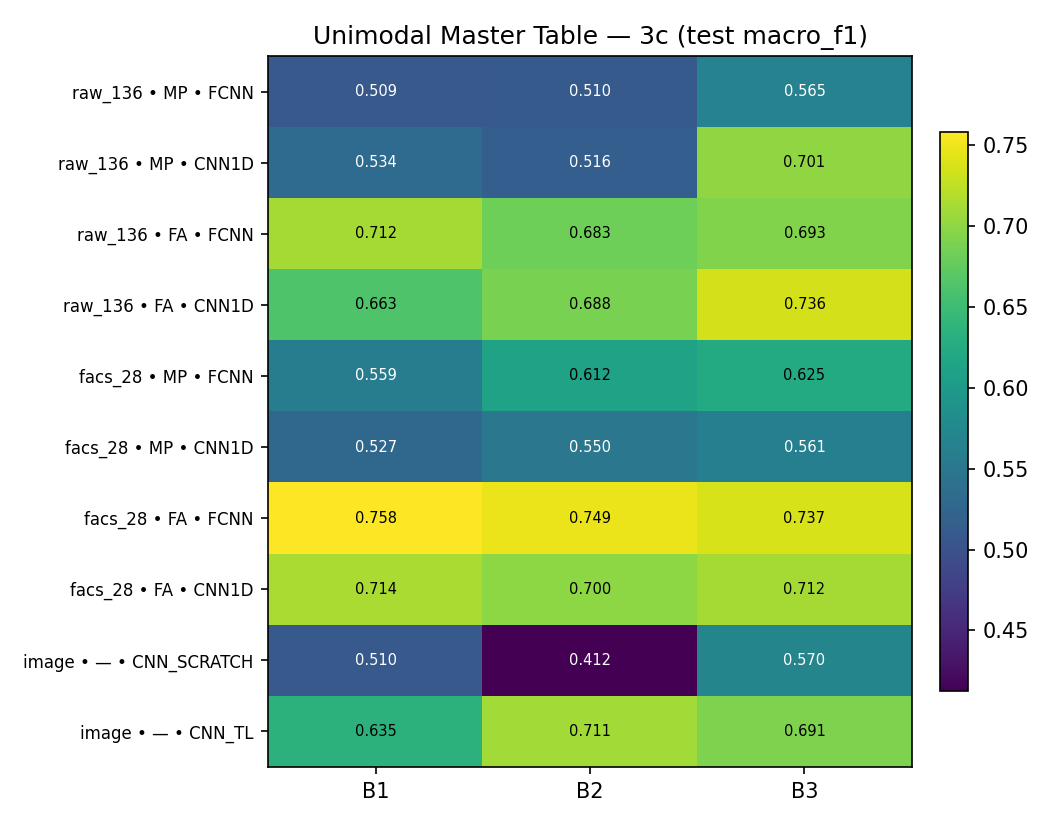

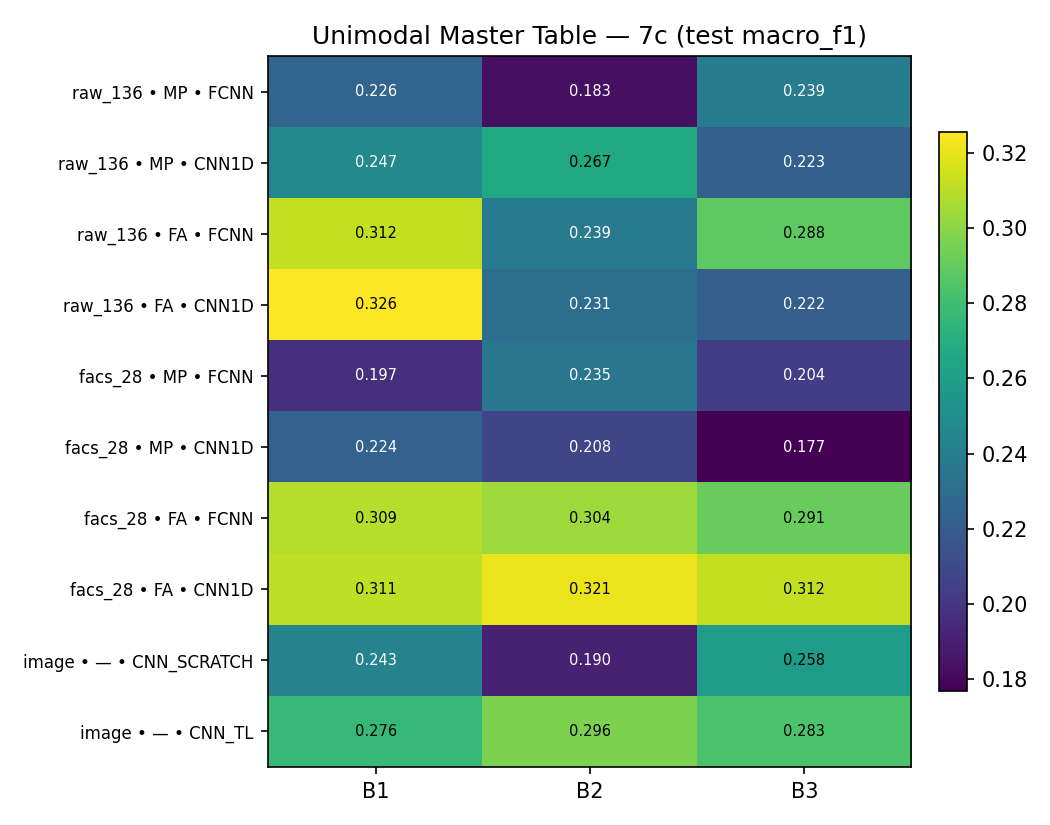

In [5]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'heatmap_master_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'heatmap_master_7c.png')))

### 4.2 Top-10 Leaderboard

Top-10 dari semua kombinasi unimodal (landmark + image) per scheme. Warna = kategori metode.


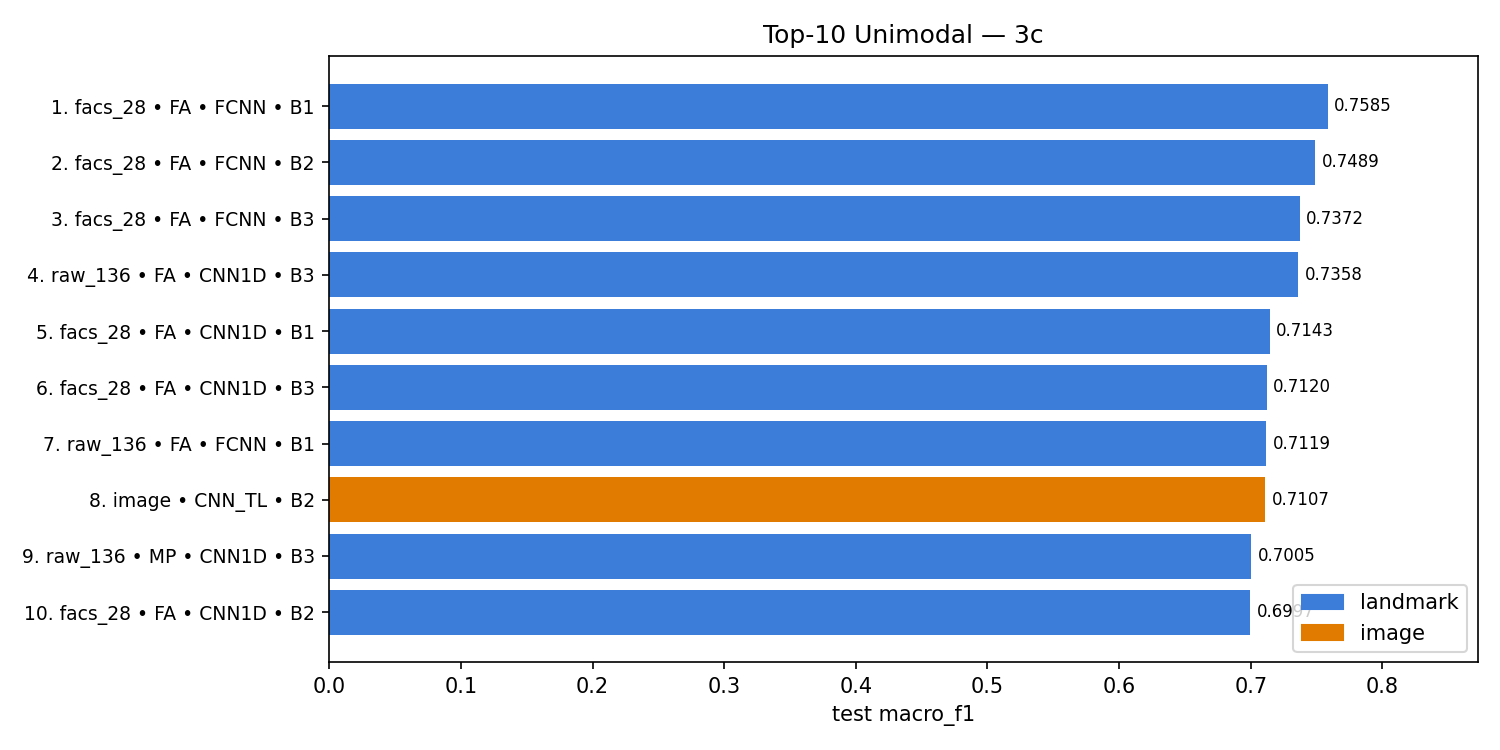

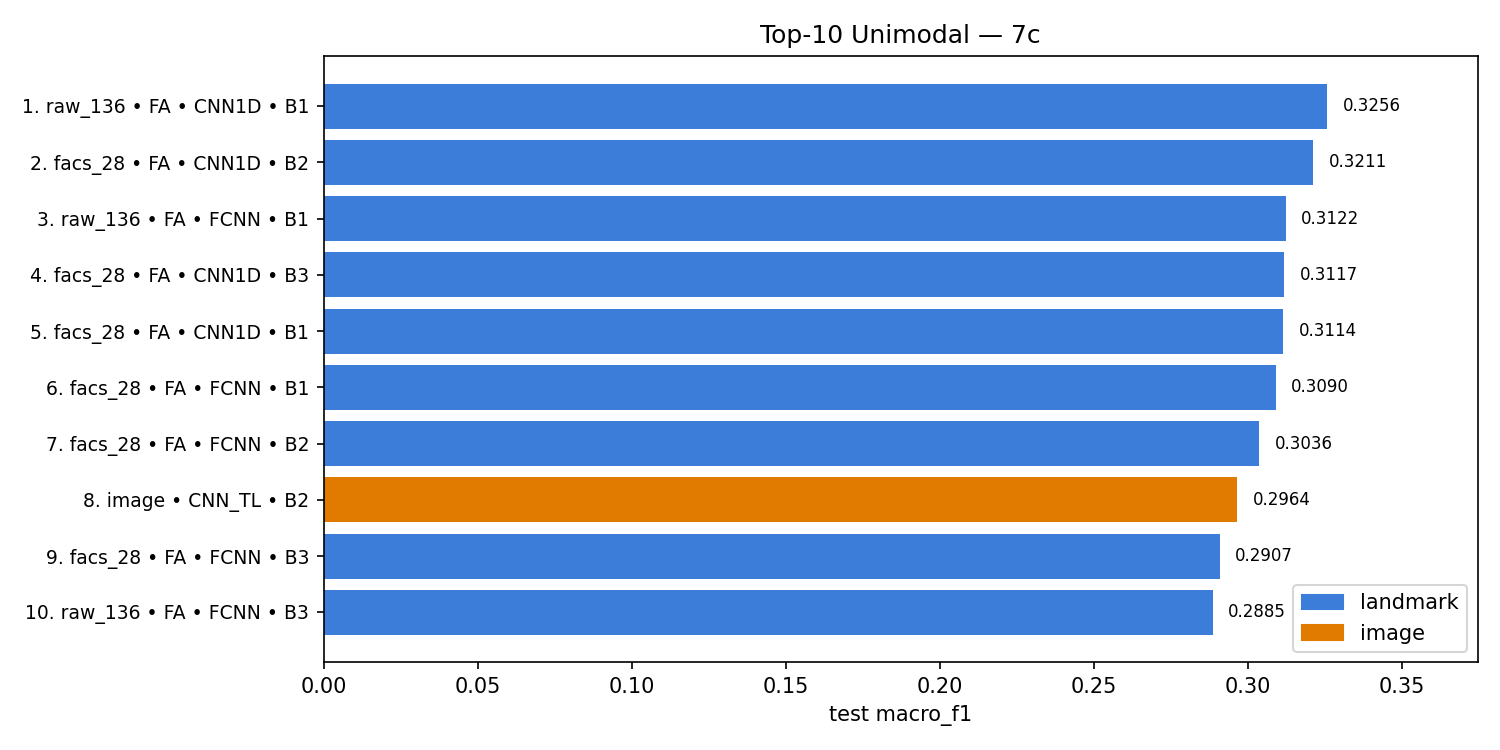

In [6]:
display(Image(filename=str(FIG_ROOT/'leaderboards'/'top10_3c.png')))
display(Image(filename=str(FIG_ROOT/'leaderboards'/'top10_7c.png')))

### 4.3 B1 / B2 / B3 Scenario Comparison

Bagaimana setiap metode merespon ke 3 imbalance scenarios?


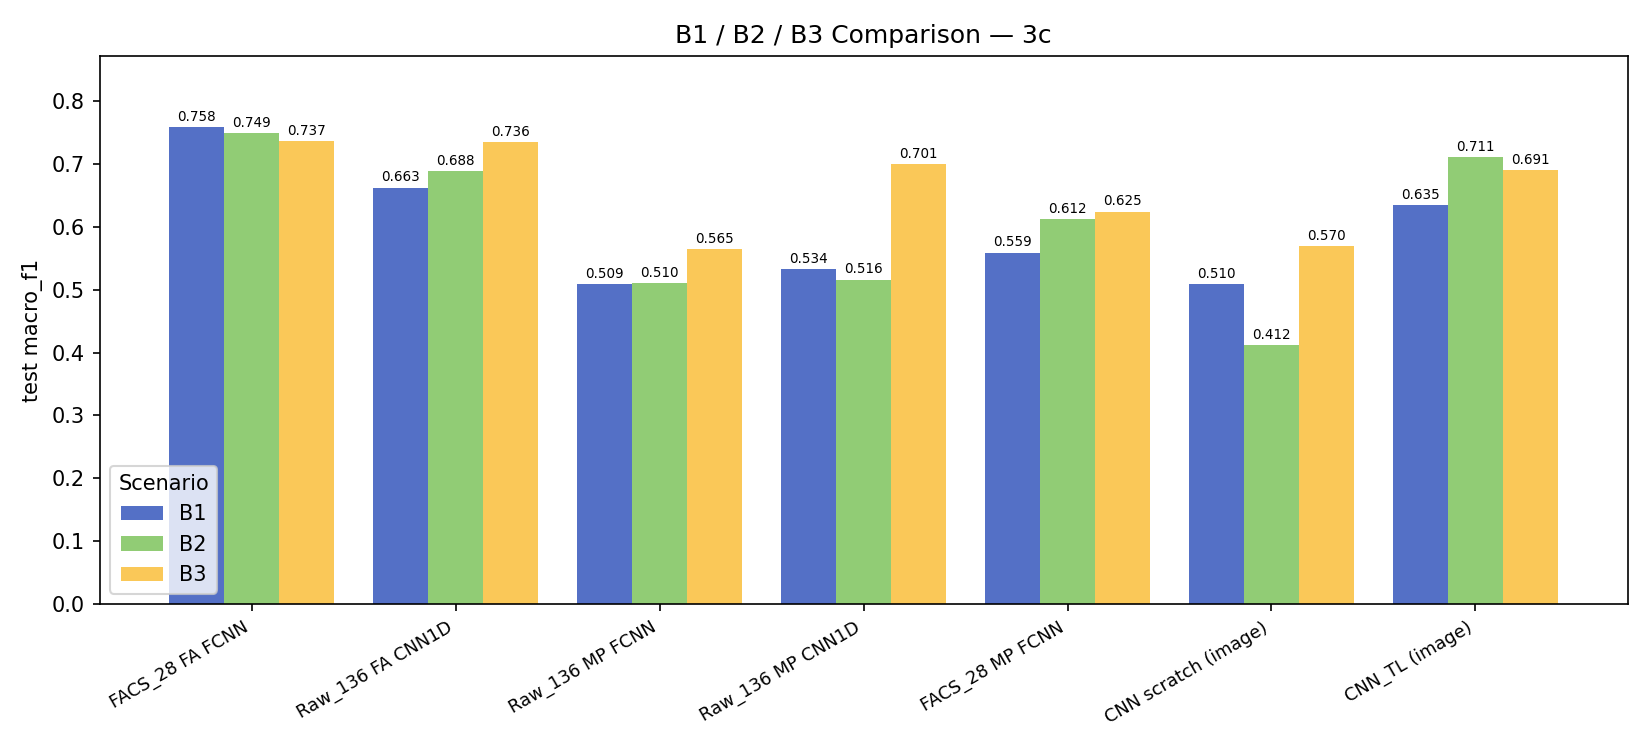

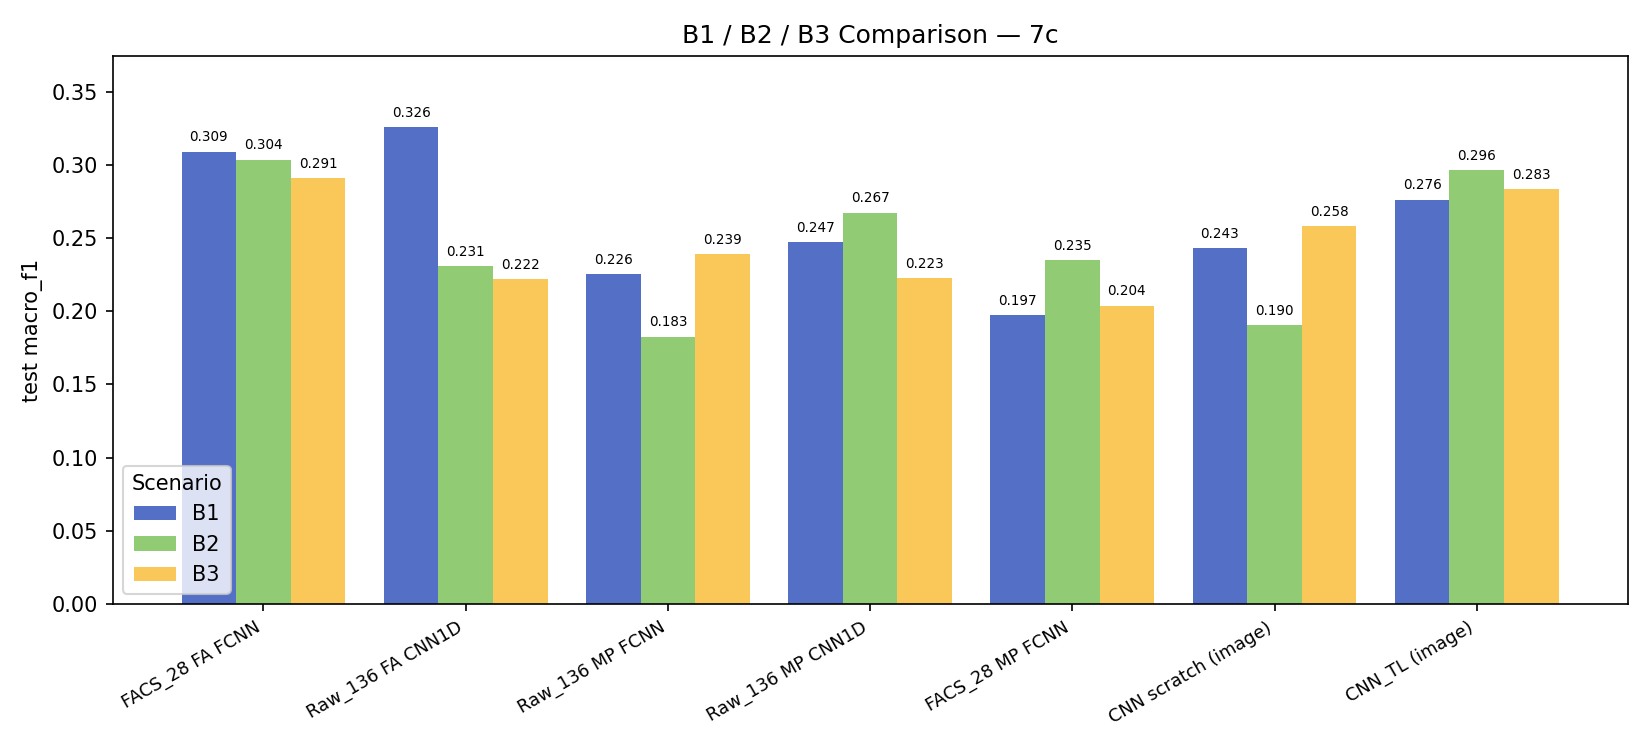

In [7]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'scenario_comparison_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'scenario_comparison_7c.png')))

### 4.4 Landmark Source: face-api.js vs MediaPipe

face-api.js (frame asli) vs MediaPipe (post face-crop 224×224, 478→68 mapping).


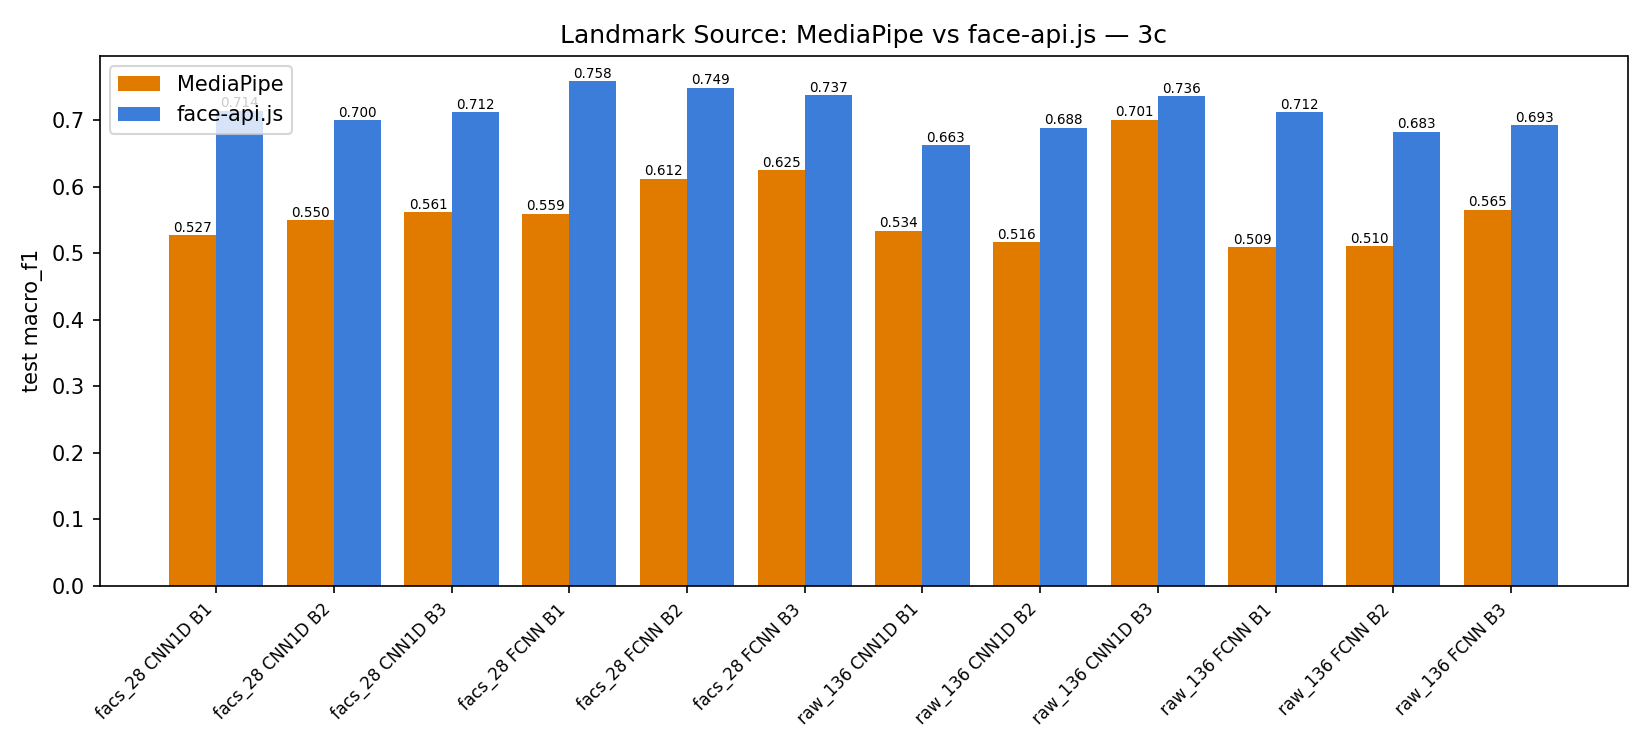

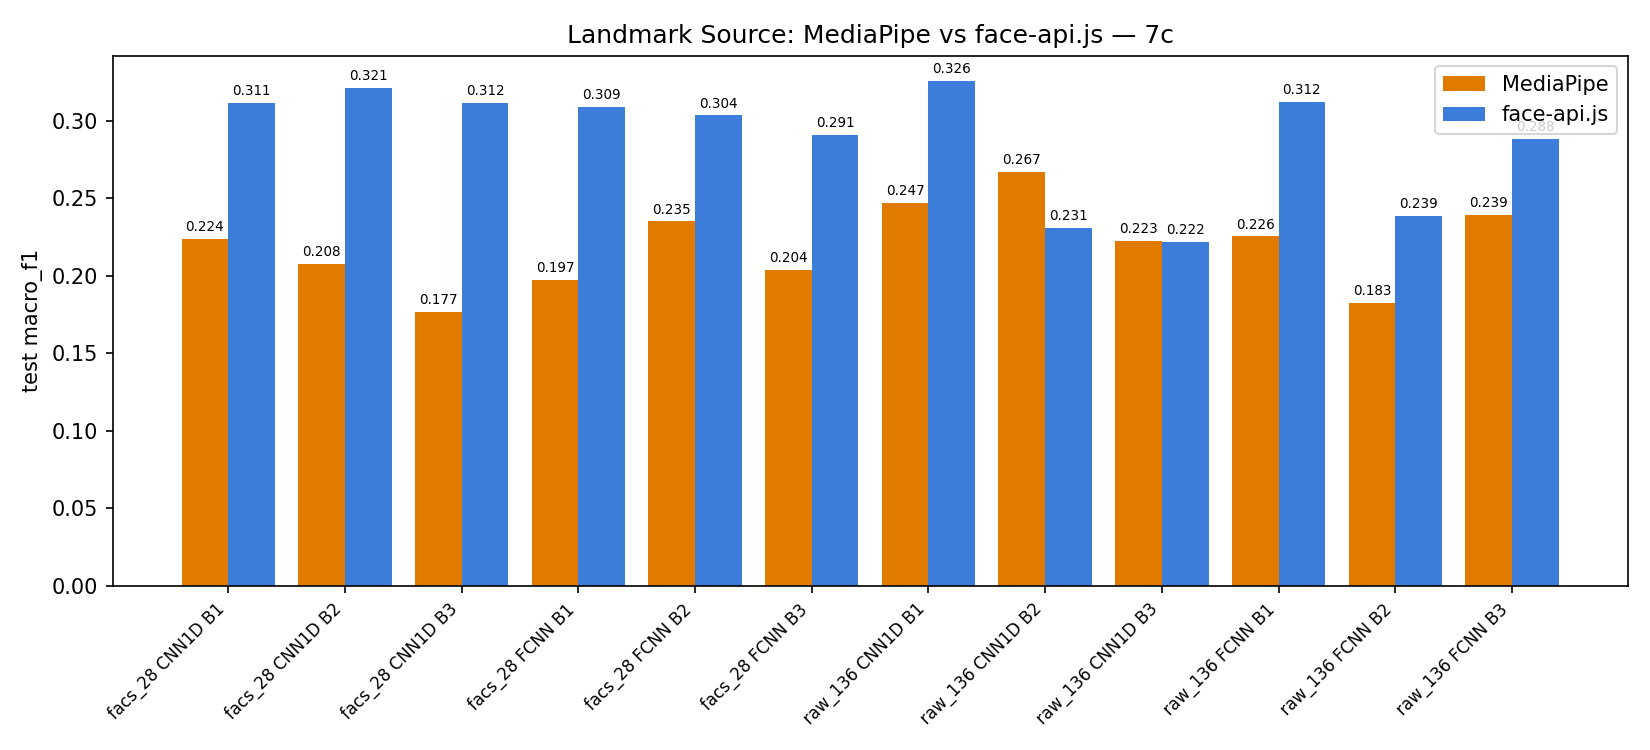

In [8]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'fa_vs_mp_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'fa_vs_mp_7c.png')))

### 4.5 Feature Comparison

Mean macro_f1 (atas arch × scenario) untuk tiap representasi landmark, dipecah per source. Error bar = range across arch × scenario.


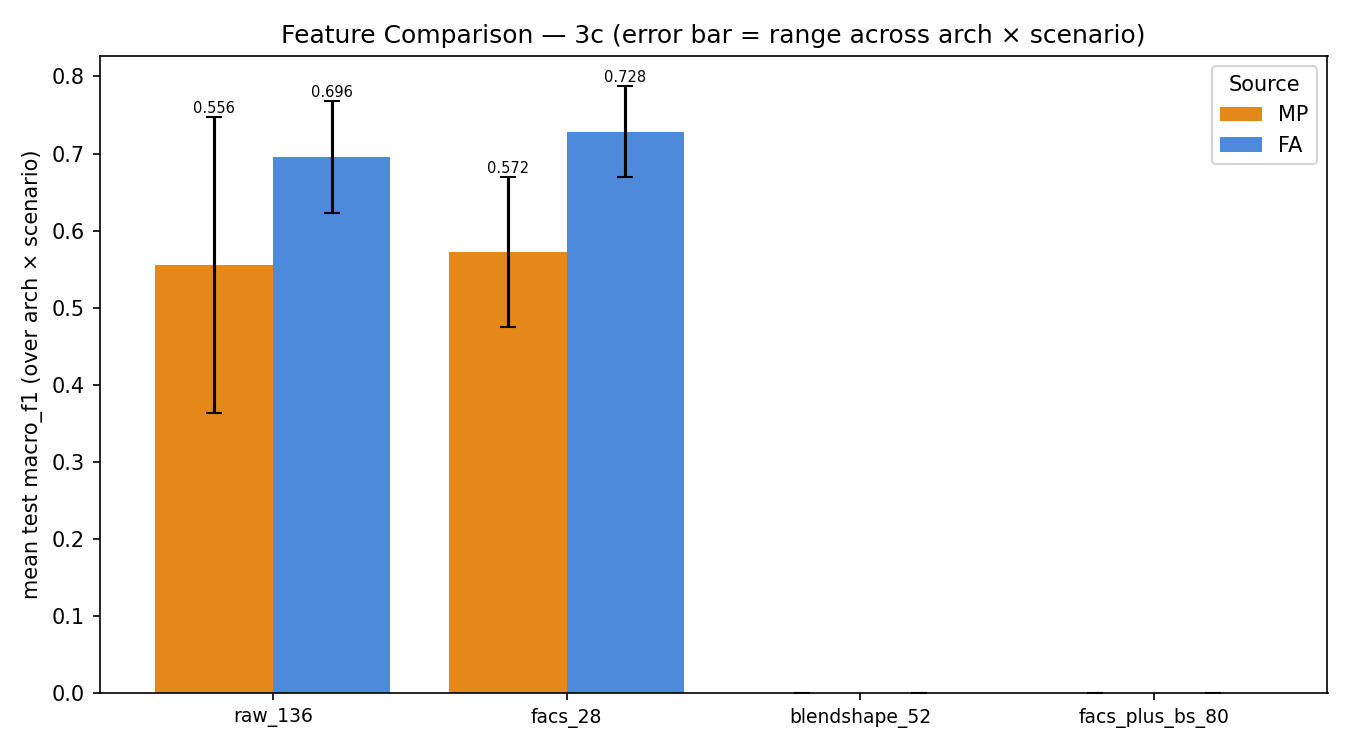

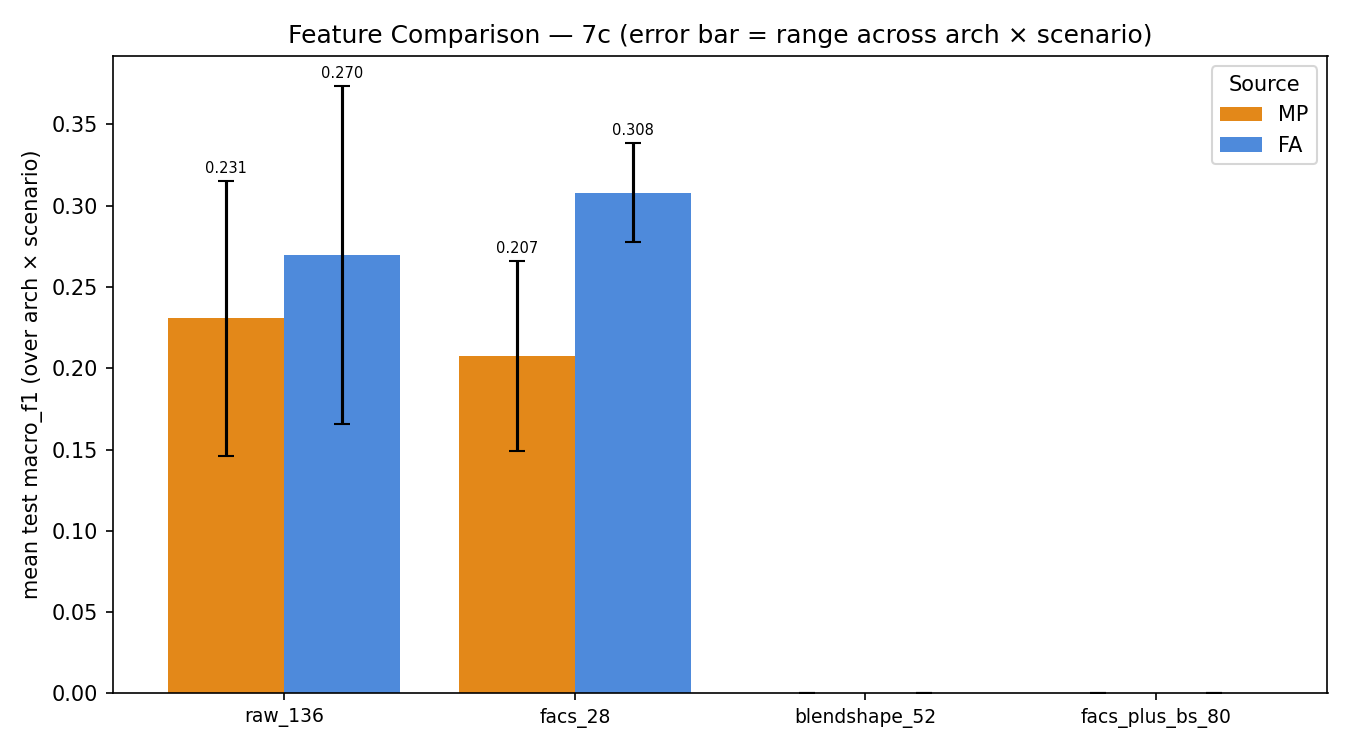

In [9]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'feature_comparison_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'feature_comparison_7c.png')))

### 4.6 Architecture Comparison: FCNN vs CNN1D

Mean macro_f1 (atas scenarios) untuk FCNN vs CNN1D pada tiap (feature, source).


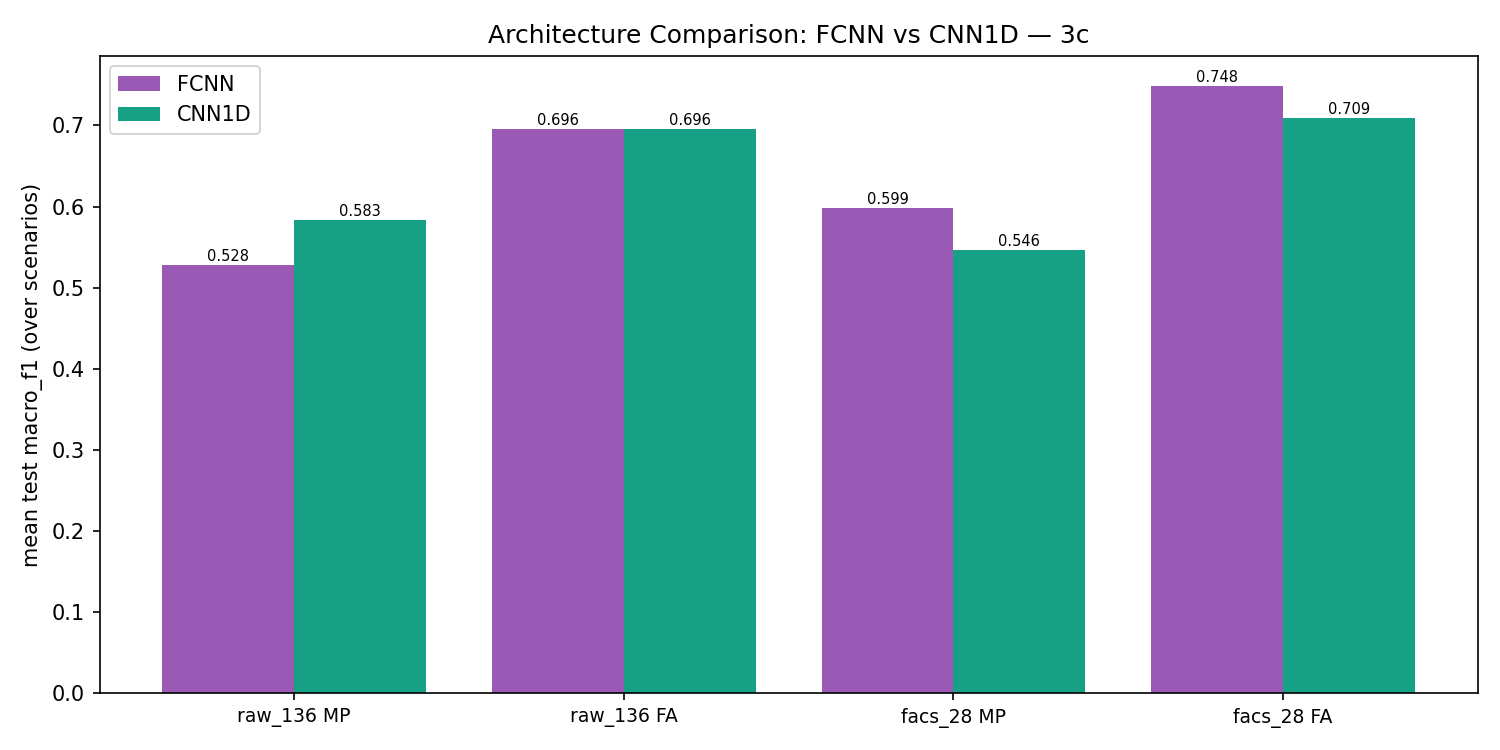

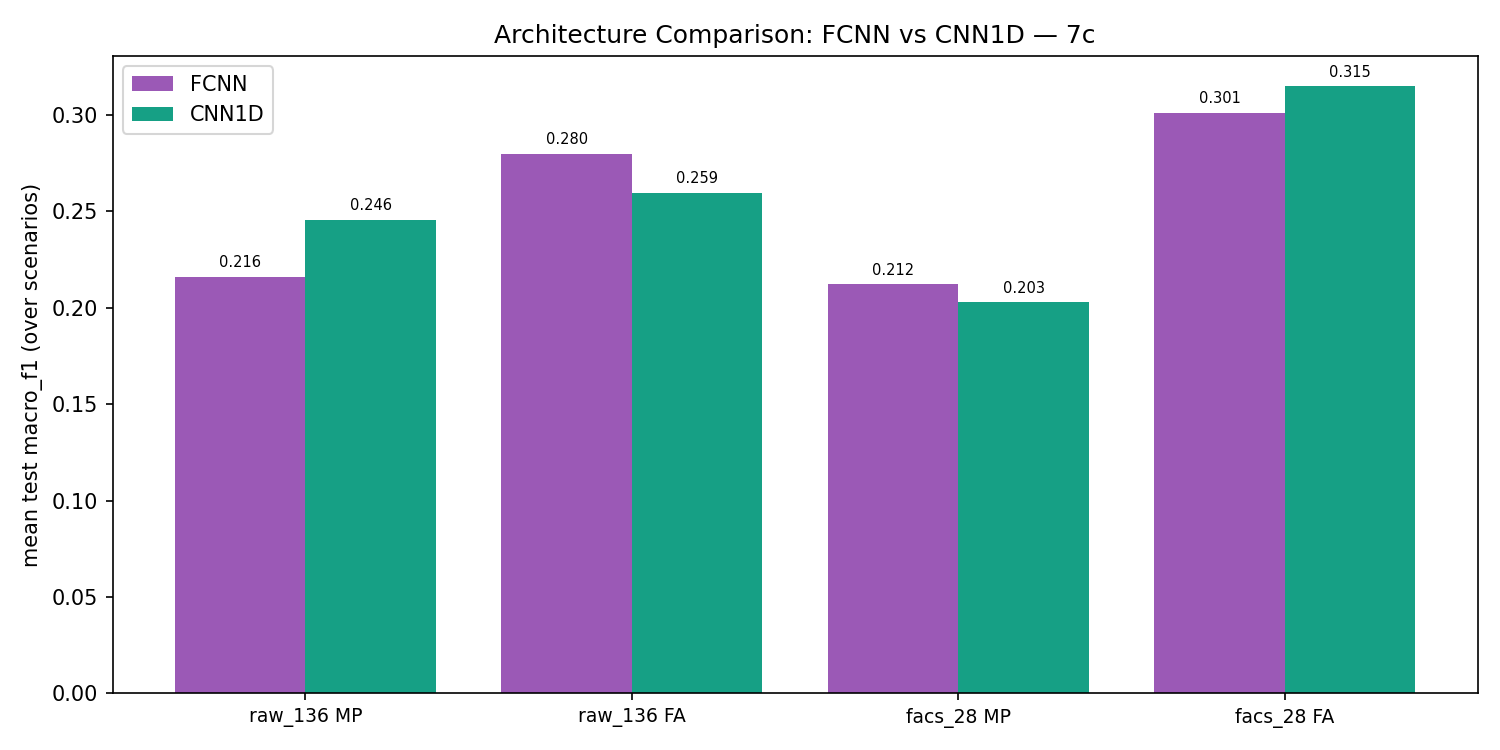

In [10]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'arch_comparison_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'arch_comparison_7c.png')))

### 4.7 Confusion Matrices — Top Model per Kategori


--- best landmark 3c ---


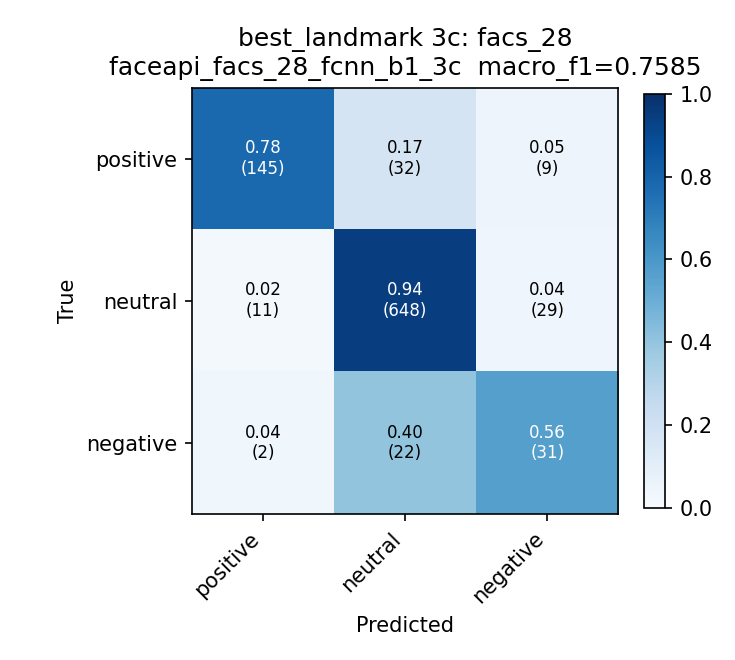

--- best image 3c ---


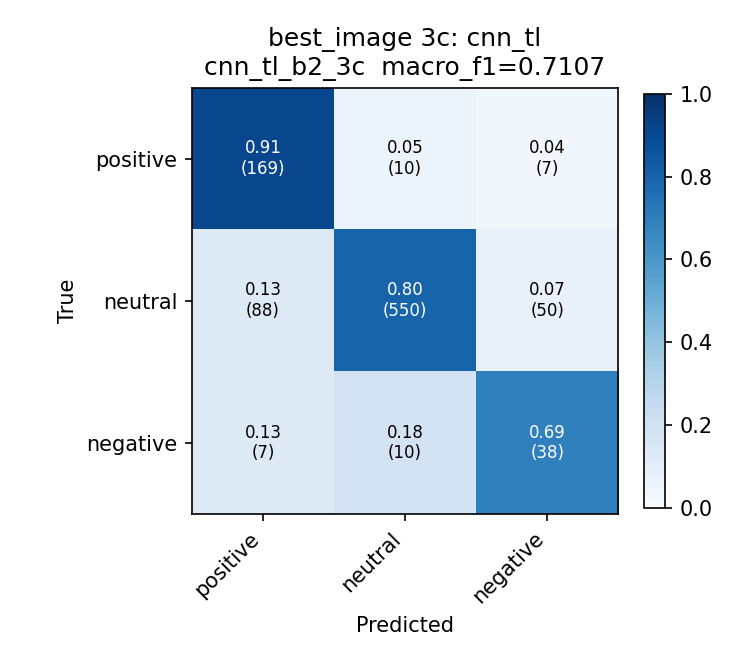

--- best landmark 7c ---


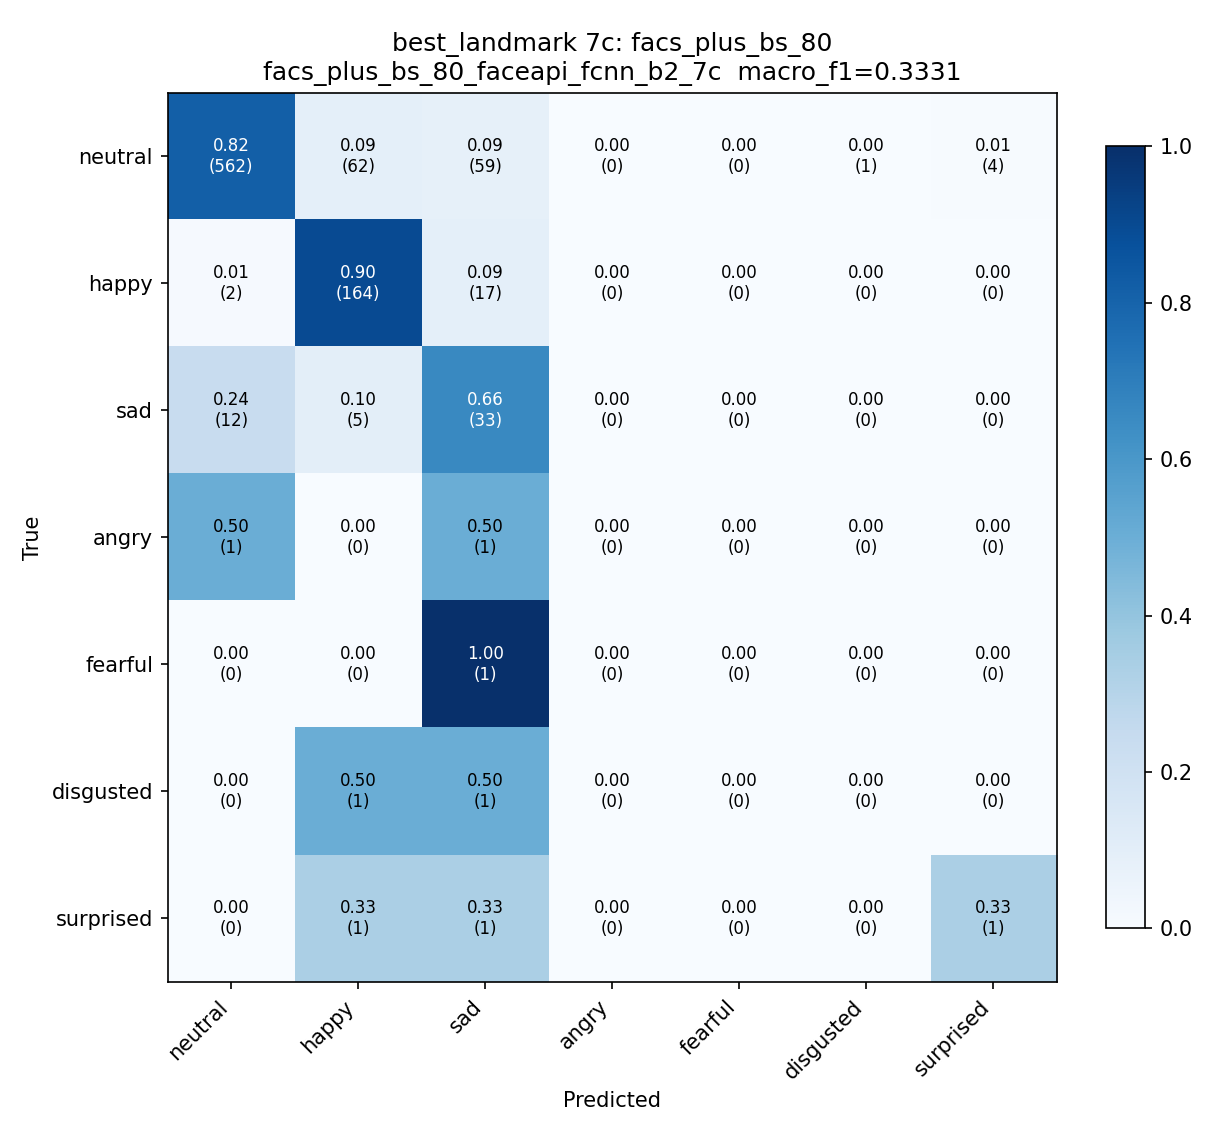

--- best image 7c ---


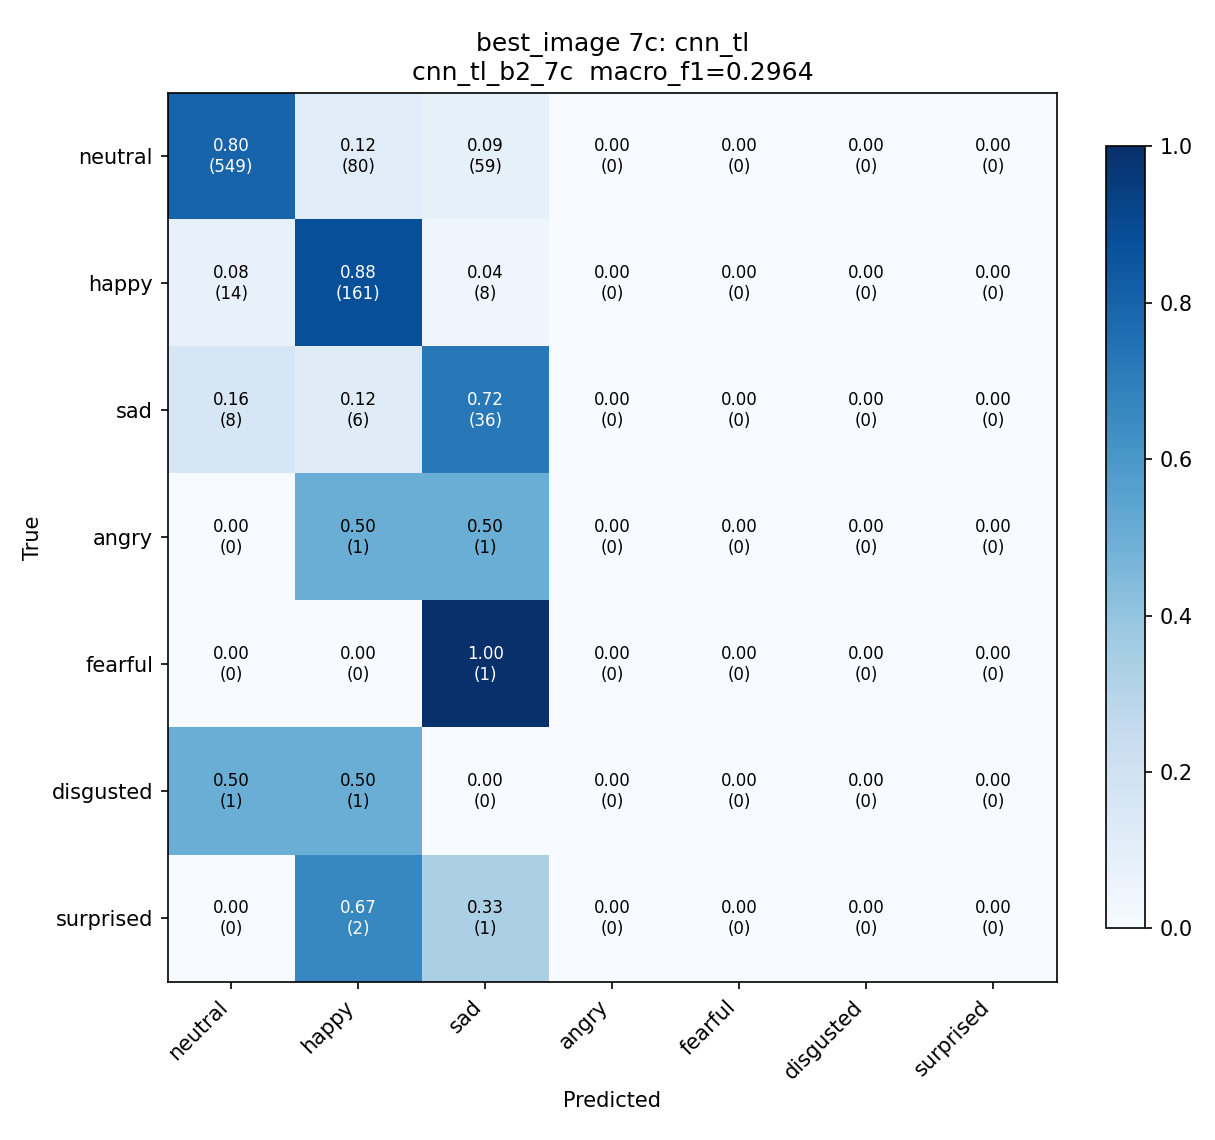

In [11]:
print('--- best landmark 3c ---')
display(Image(filename=str(FIG_ROOT/'confusion_matrices'/'best_landmark_3c.png')))
print('--- best image 3c ---')
display(Image(filename=str(FIG_ROOT/'confusion_matrices'/'best_image_3c.png')))
print('--- best landmark 7c ---')
display(Image(filename=str(FIG_ROOT/'confusion_matrices'/'best_landmark_7c.png')))
print('--- best image 7c ---')
display(Image(filename=str(FIG_ROOT/'confusion_matrices'/'best_image_7c.png')))

### 4.8 Per-class F1 — Top-3 Models

F1 per kelas untuk top-3 model unimodal. Berguna untuk melihat dampak class imbalance ke kelas minoritas.


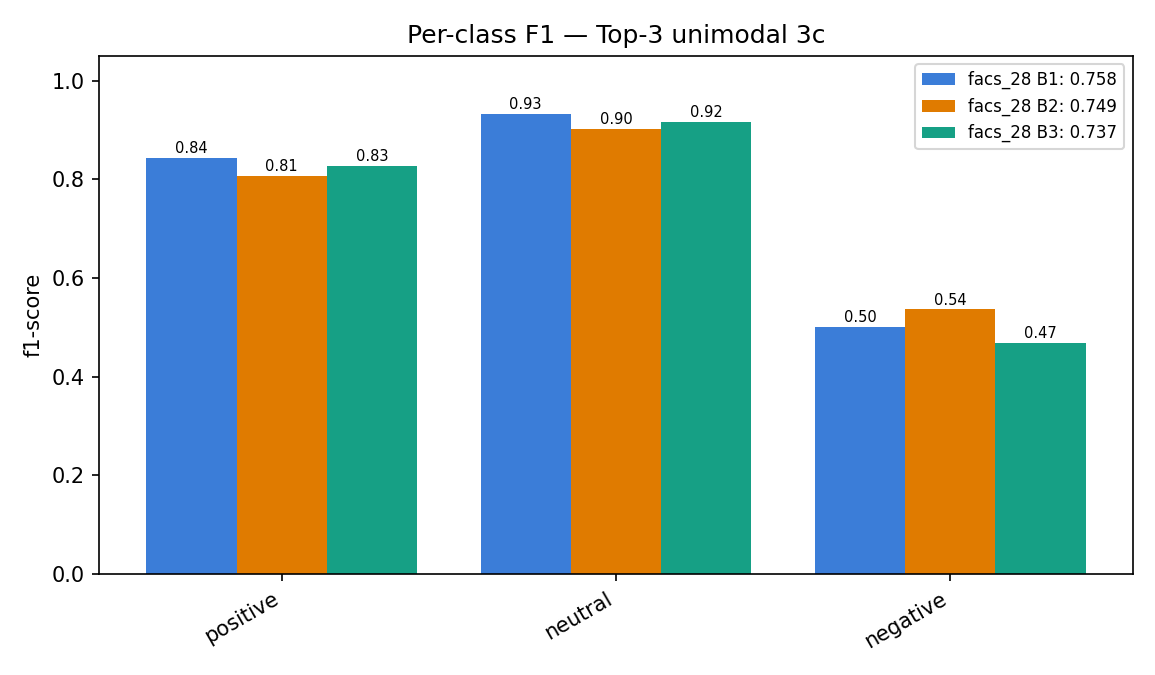

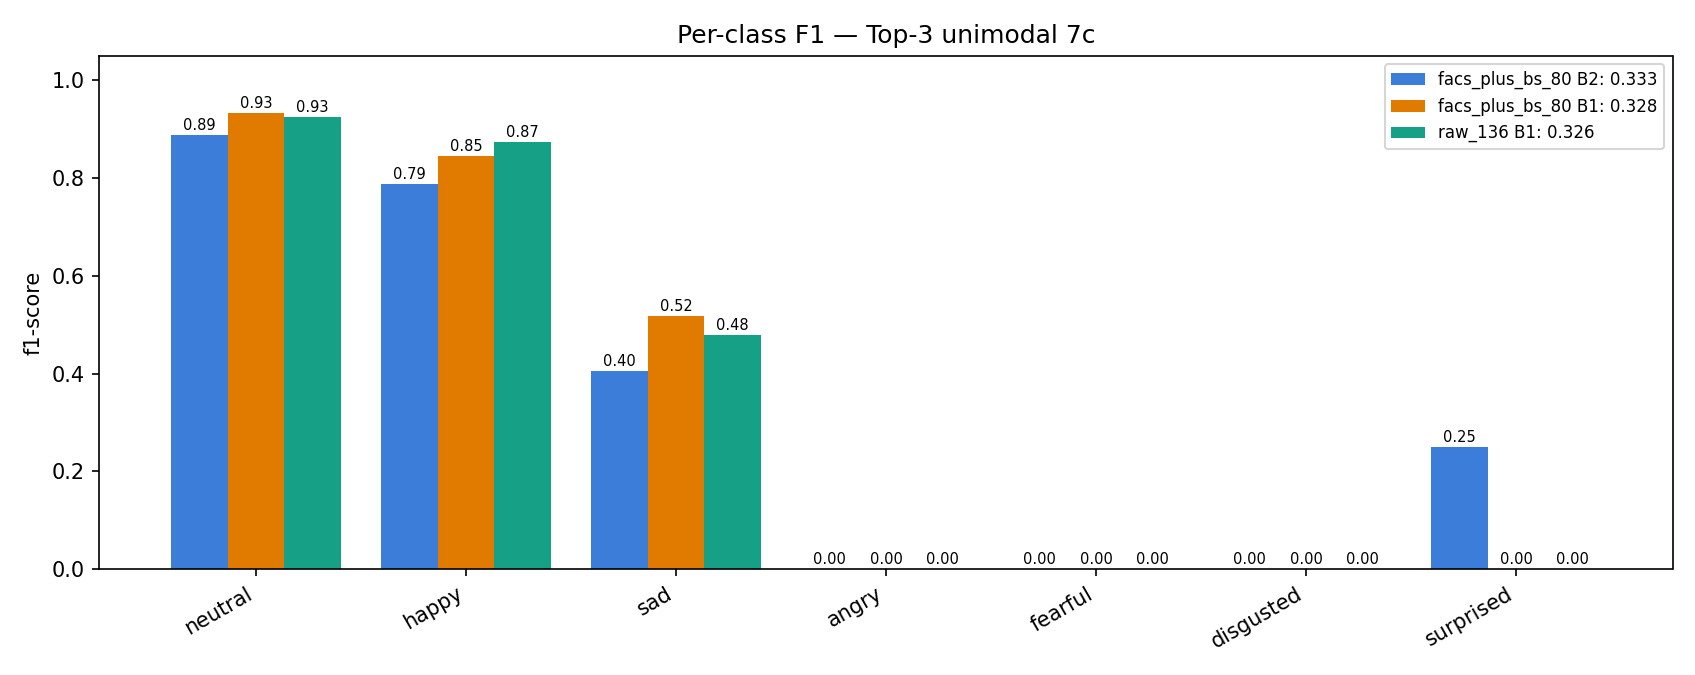

In [12]:
display(Image(filename=str(FIG_ROOT/'per_class'/'top3_per_class_f1_3c.png')))
display(Image(filename=str(FIG_ROOT/'per_class'/'top3_per_class_f1_7c.png')))

### 4.9 Training Curves — Top-3 per Kategori

Per-epoch `val_macro_f1` untuk top-3 landmark + top-3 image. Bintang ⭐ = best epoch yang dipilih untuk evaluasi test.


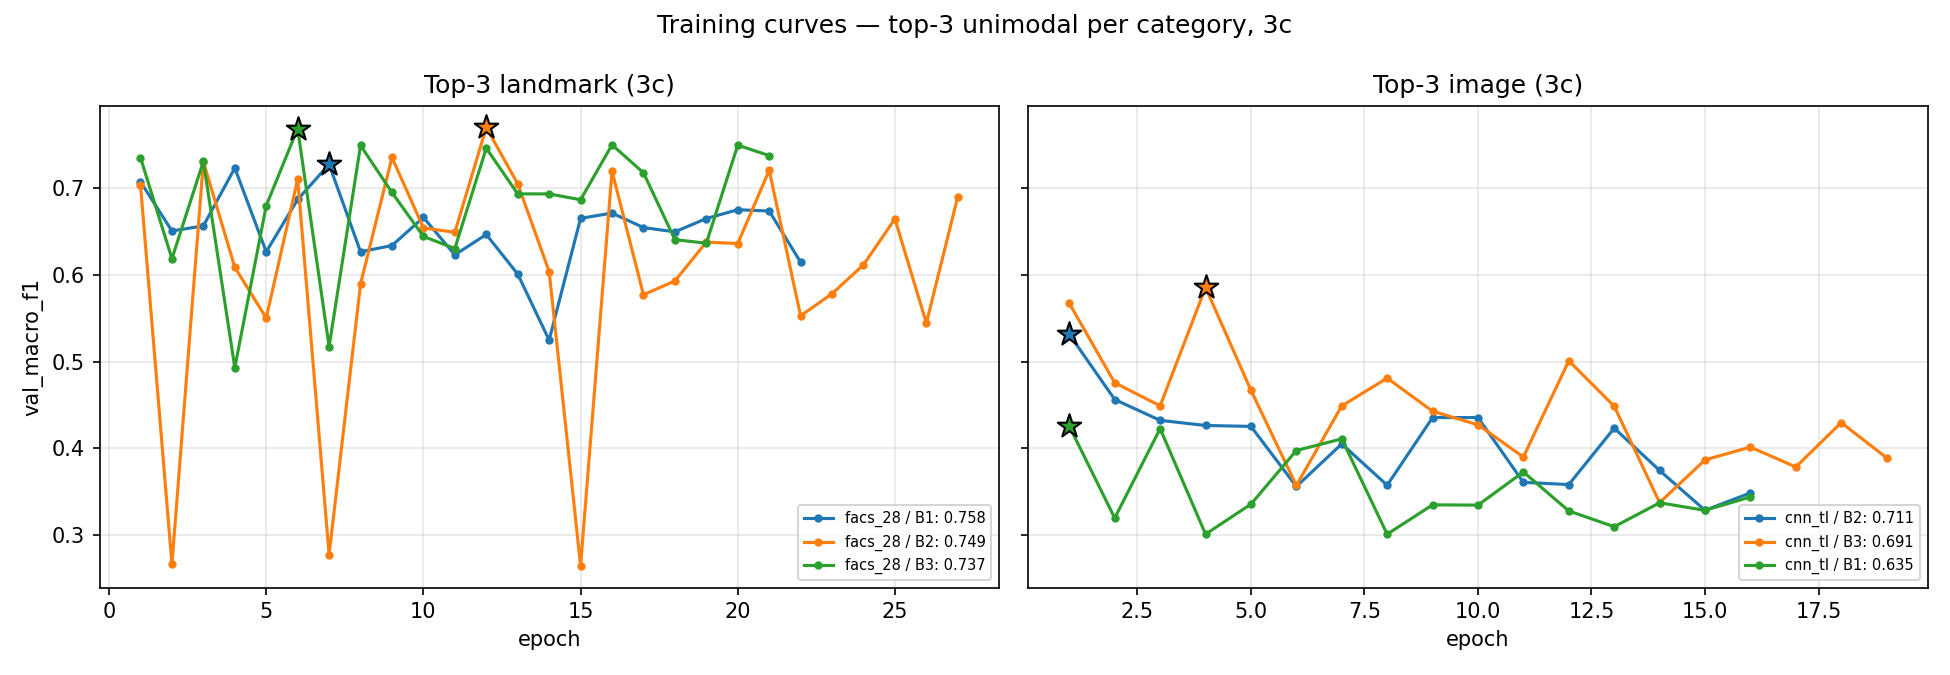

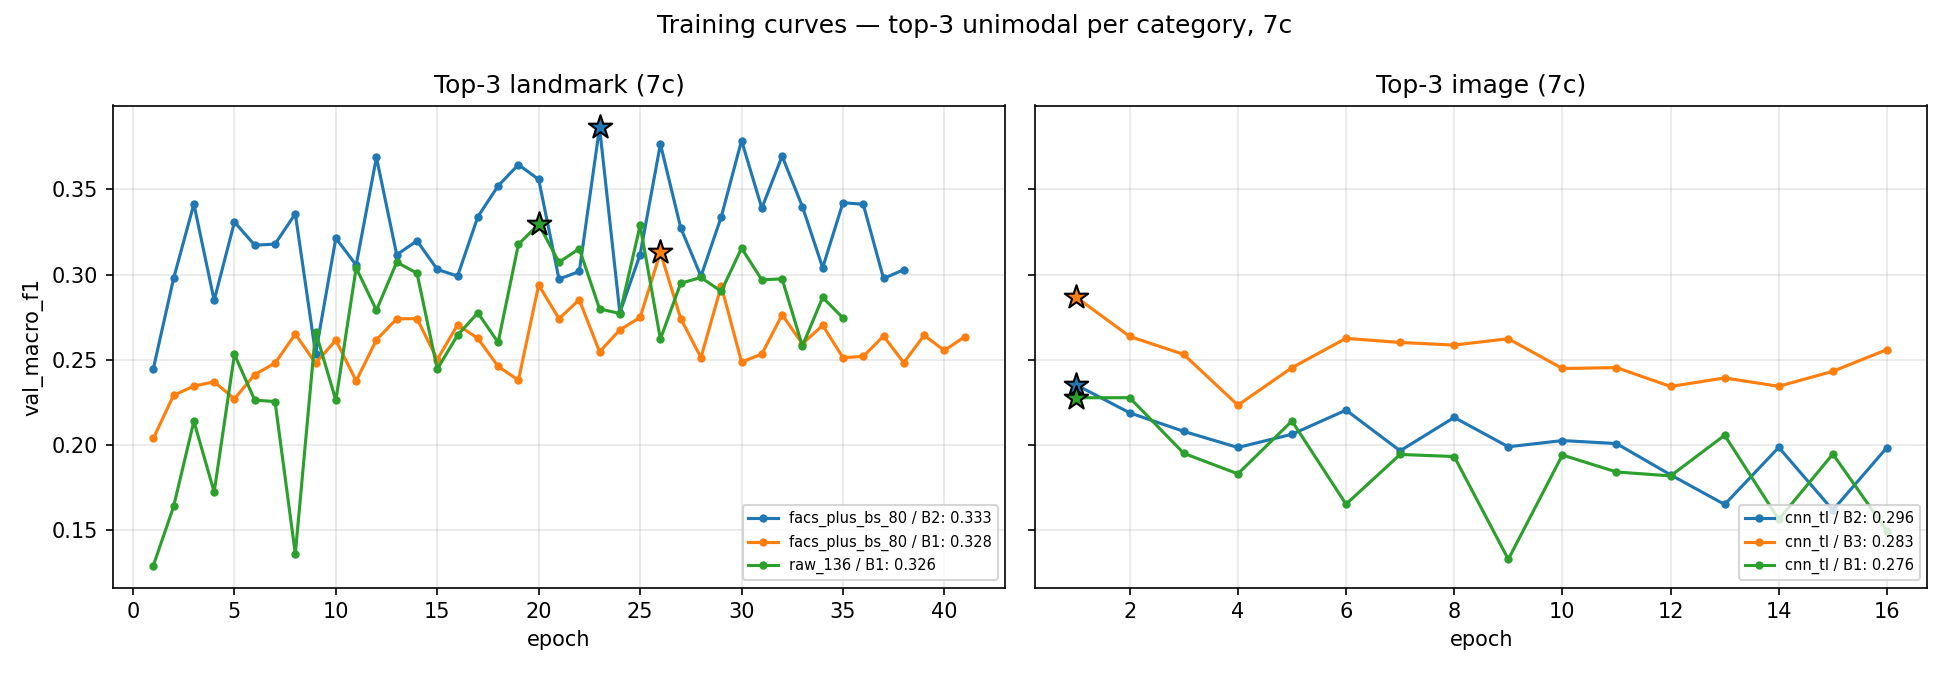

In [13]:
display(Image(filename=str(FIG_ROOT/'training_curves'/'top3_3c.png')))
display(Image(filename=str(FIG_ROOT/'training_curves'/'top3_7c.png')))

### 4.10 Resource Usage

Training time, model size (params), dan peak VRAM untuk tiap metode (mean across scenarios).


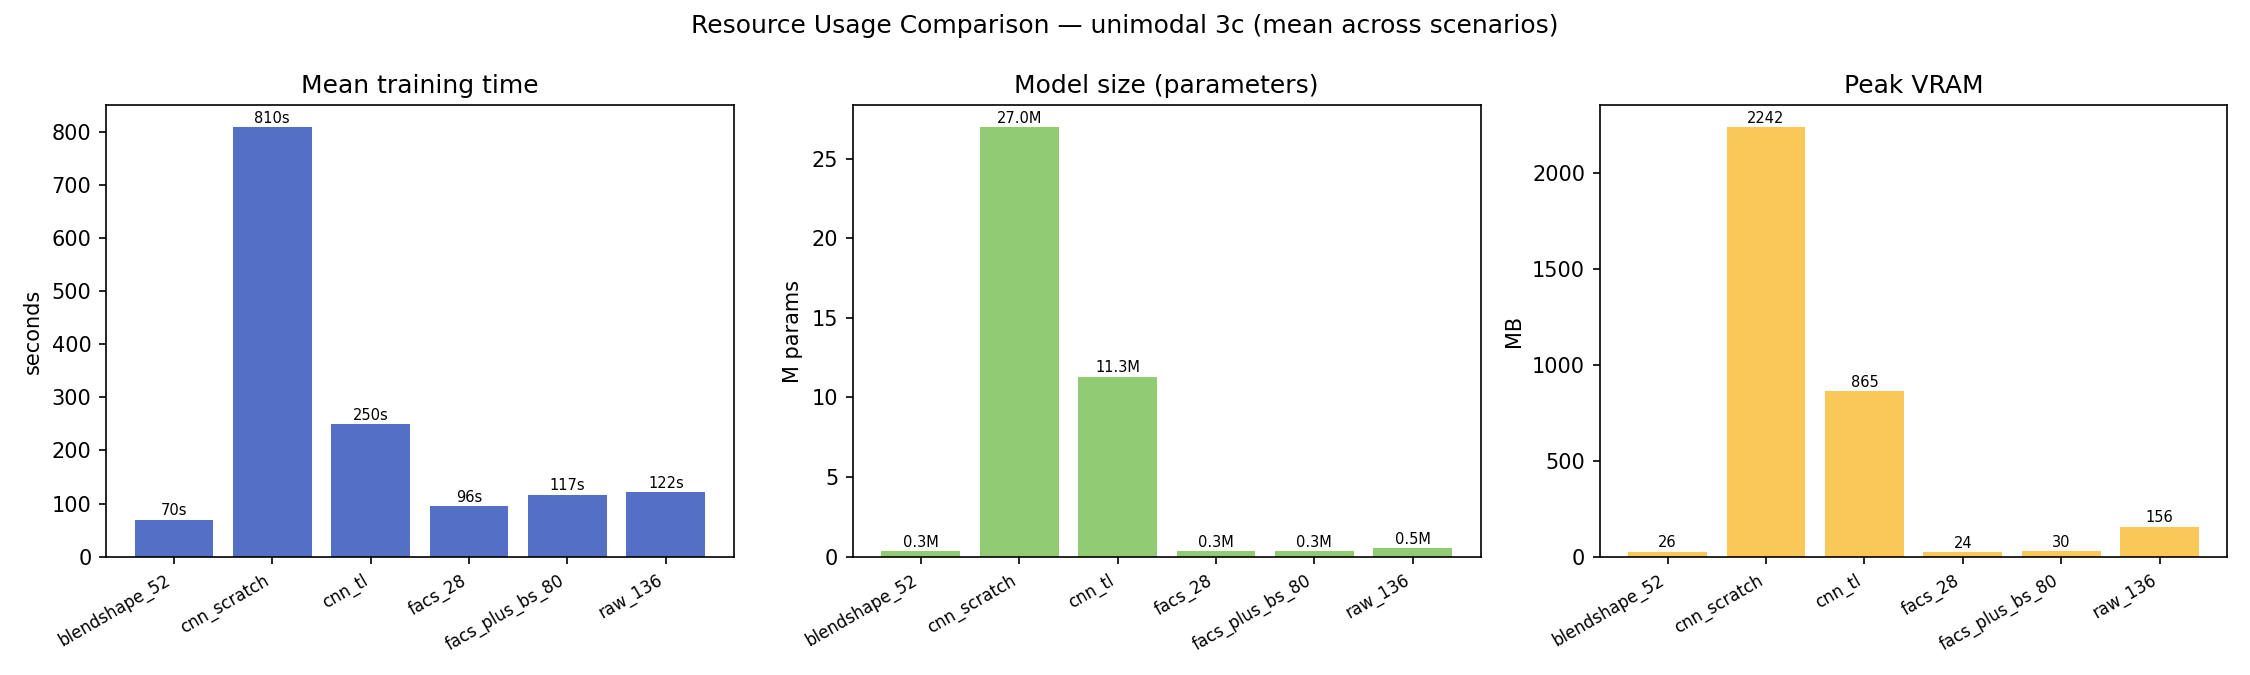

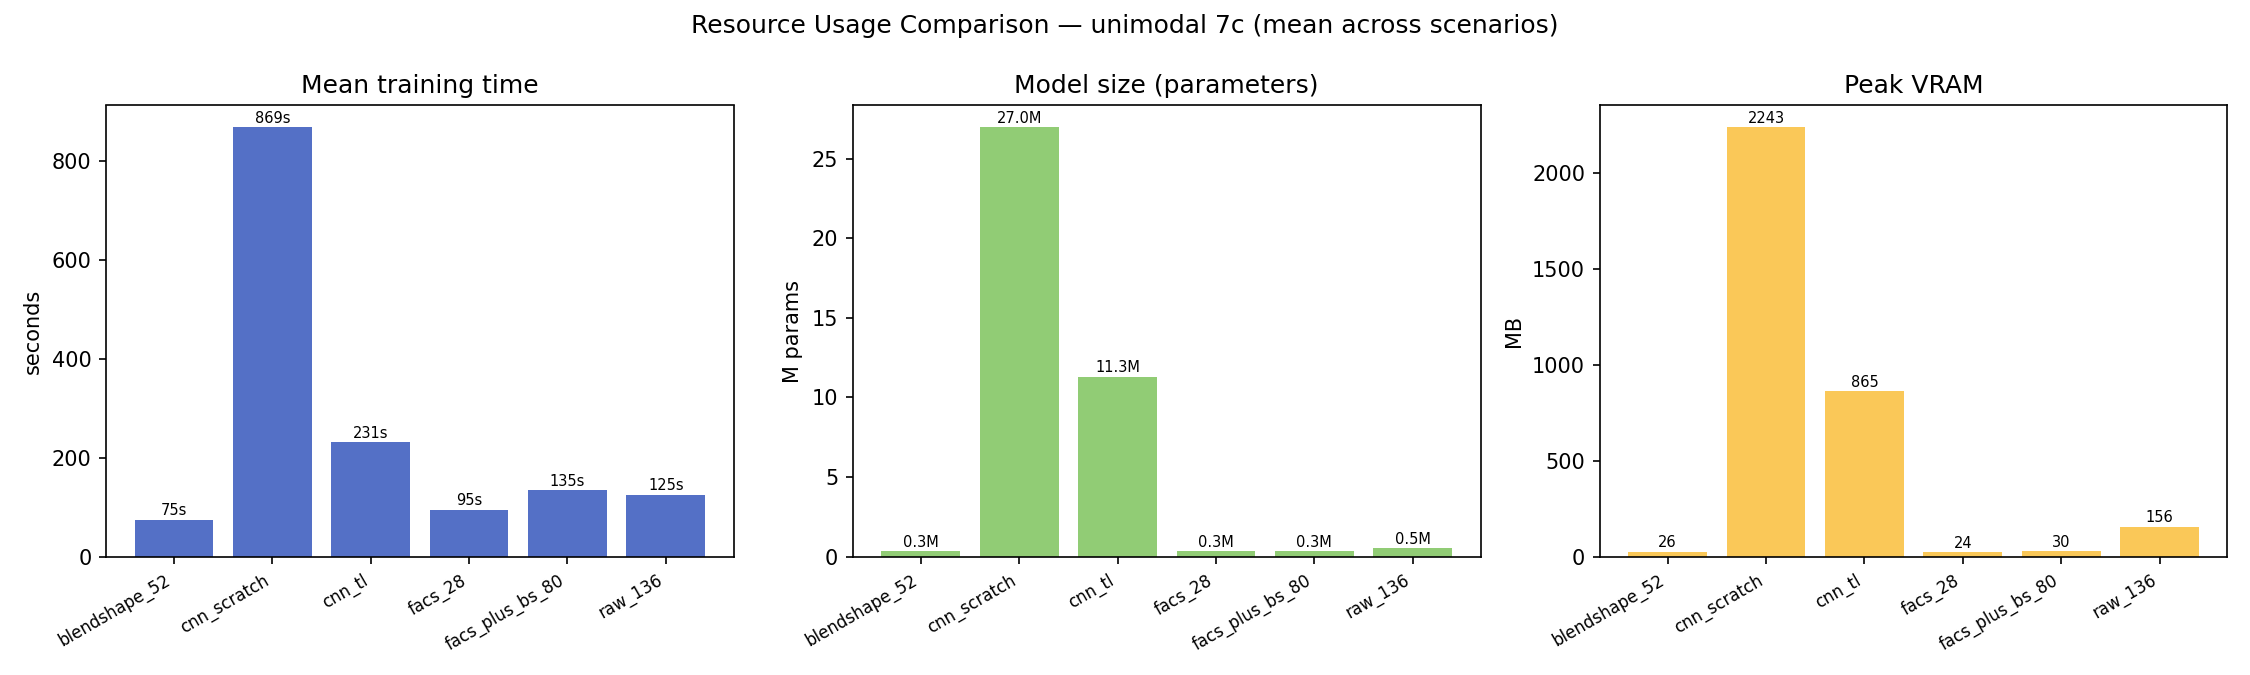

In [14]:
display(Image(filename=str(FIG_ROOT/'resources'/'resource_compare_3c.png')))
display(Image(filename=str(FIG_ROOT/'resources'/'resource_compare_7c.png')))

### 4.11 Class Distribution: Primer vs KDEF

Primer punya class imbalance ekstrem (~2263:1 di 7c), KDEF perfectly balanced (~334-338/class).


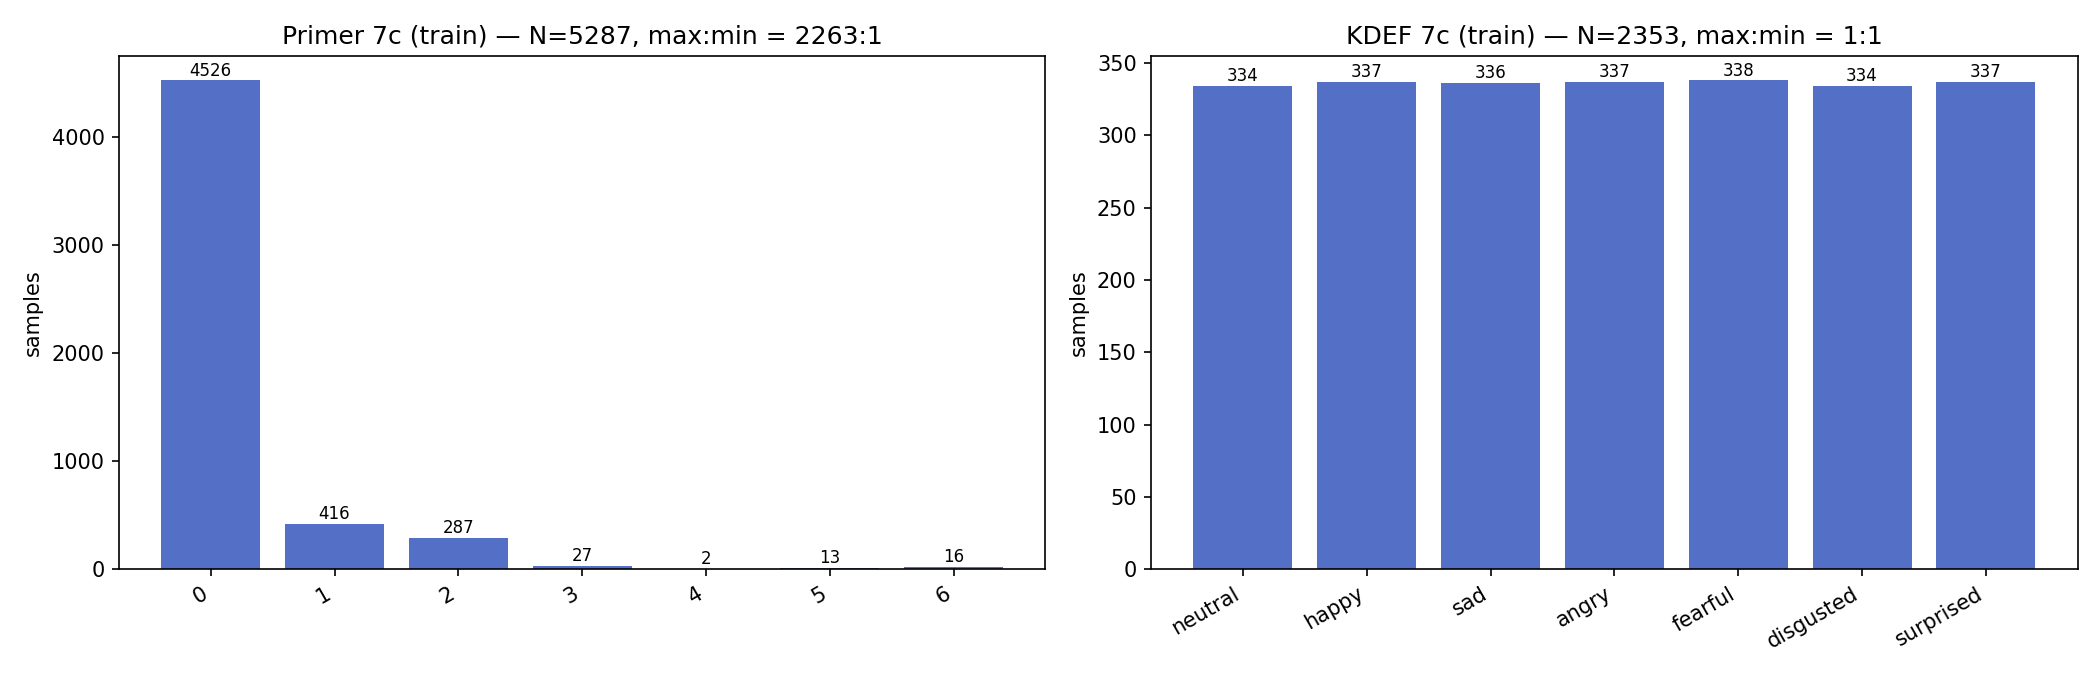

In [15]:
display(Image(filename=str(FIG_ROOT/'dataset'/'class_distribution.png')))

### 4.12 Cross-dataset: Primer vs KDEF

Apakah ranking method konsisten antara dataset Primer (in-the-wild, imbalanced) dan KDEF (controlled lab, balanced)? Comparison di scenario B1, source MediaPipe.


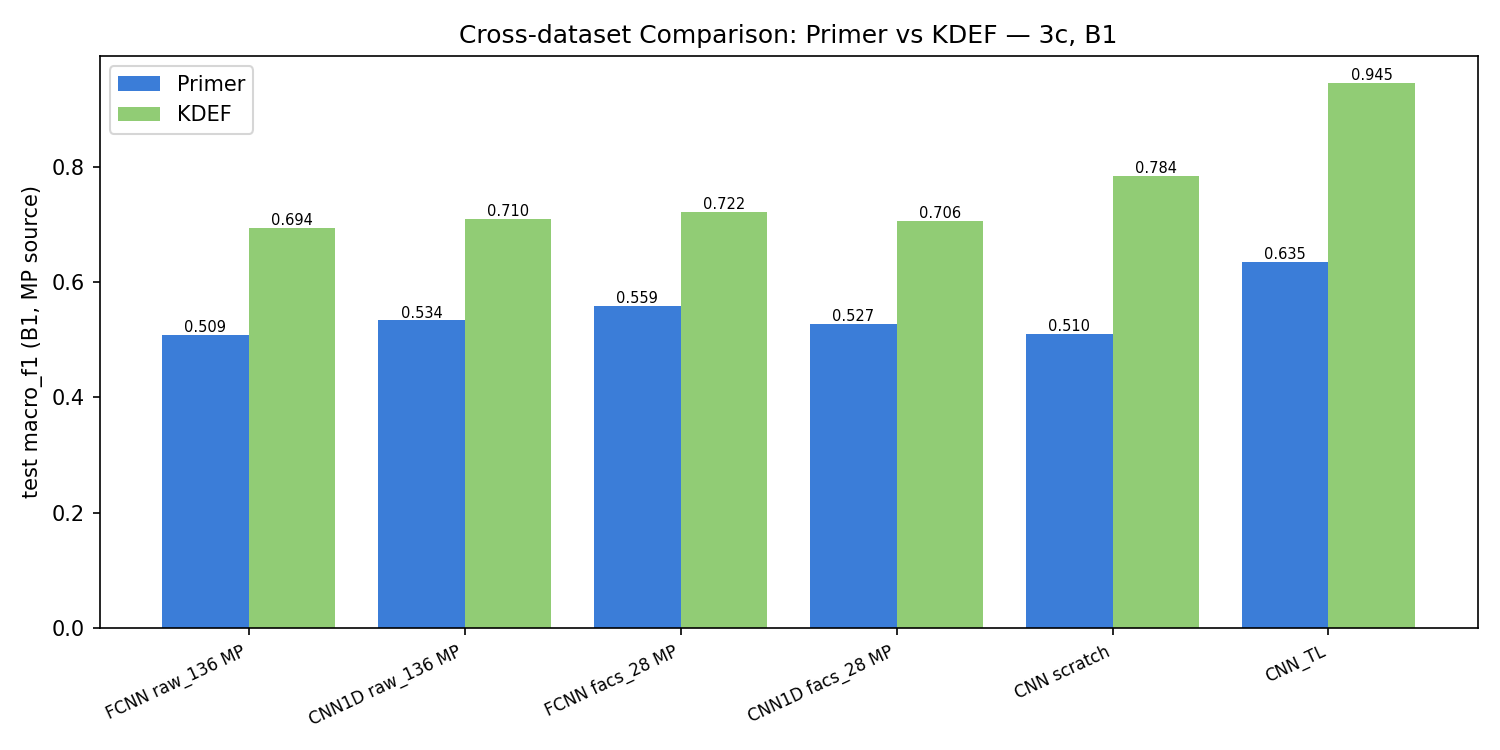

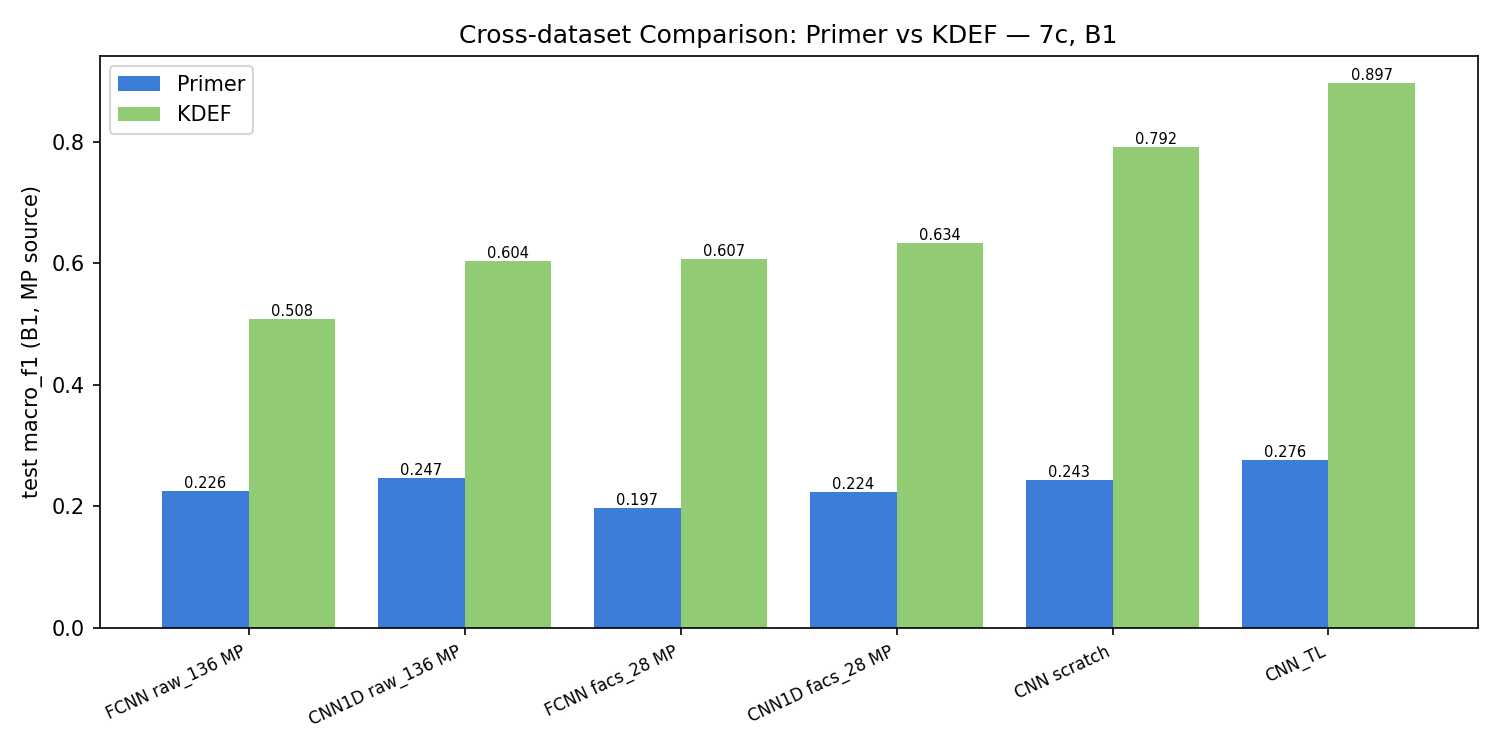

In [16]:
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_kdef_3c.png')))
display(Image(filename=str(FIG_ROOT/'comparisons'/'primer_vs_kdef_7c.png')))

## 5. Insight Utama

### Best per scheme (Primer)
- **3c top:** FACS_28 × FA × FCNN × B1 = **0.7585**
- **7c top:** FACS+Blendshape (80) × FA × FCNN × B2 = **0.3331**

### Pola yang konsisten
- **face-api.js > MediaPipe** untuk landmark — semua top-10 (3c & 7c) pakai FA. Hipotesis: koordinat di frame asli (FA) mempertahankan info scale/pose, sedangkan MP (post face-crop 224×224) lebih kompresi info. Plus FA native 68-pt dlib semantik konsisten vs MP 478→68 mapping yang approximate.
- **CNN_TL ≫ CNN scratch** di image branch — pretrained ImageNet features esensial untuk dataset kecil (~5300 train sample).
- **Image-based < landmark-based** di kedua skema (best image rank ≥ 11 di leaderboard).
- **CNN1D > FCNN** untuk raw 2D coords (locality antar titik berurutan bermanfaat).
- **FCNN > CNN1D** untuk FACS distance (hand-crafted features tidak punya locality, MLP natural).
- **Scenario terbaik tergantung representasi:** B1 stabil untuk MP-source 7c, B3 menang di CNN1D + raw coords (synergy locality + aug), B2 menang di derived features 7c & image CNN_TL.

### Class imbalance bottleneck (7c)
- Train counts 7c: `[4526 neutral, 416 happy, 287 sad, 27 angry, 2 fearful, 13 disgusted, 16 surprised]`
- Rasio max:min = **2263:1** → kelas minoritas 1-3 sample di test set → metric noise tinggi
- 3c remap (positive = happy+surprised, neutral, negative = sisanya) jauh lebih wajar untuk eval.

### Cross-dataset (KDEF, B1 MP)
- CNN_TL ≫ method lain di KDEF balanced 7c (0.8966) — image branch lebih menonjol di dataset balanced.
- Landmark FCNN 7c di KDEF turun signifikan dibanding ekspektasi — perlu invest tuning per-method LR untuk landmark FCNN, atau pakai LR scheduler.

---

*Notebook di-regenerate dengan `python scripts/build_unimodal_notebook.py`. Figure di-regenerate dengan `python scripts/build_unimodal_figures.py`.*
